<a href="https://colab.research.google.com/github/MatiasMoreno707/lab08-lp/blob/dev/lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
# pip install graphviz pydotplus

### a. Lea la base de datos, realice imputaciones, tratamiento de outliers, transformaciones de datos y desbalance de clases en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'

columnas = [
    "Sample_code_number", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
    "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
    "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"
]

In [18]:
df = pd.read_csv(url, names=columnas)
df.head()

,Sample_code_number,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [19]:
df.drop('Sample_code_number', axis=1, inplace=True)

In [6]:
df.shape

(699, 11)

In [20]:
df.dtypes

,0
Clump_Thickness,int64
Uniformity_Cell_Size,int64
Uniformity_Cell_Shape,int64
Marginal_Adhesion,int64
Single_Epithelial_Cell_Size,int64
Bare_Nuclei,object
Bland_Chromatin,int64
Normal_Nucleoli,int64
Mitoses,int64
Class,int64


In [21]:
df.isnull().sum()

,0
Clump_Thickness,0
Uniformity_Cell_Size,0
Uniformity_Cell_Shape,0
Marginal_Adhesion,0
Single_Epithelial_Cell_Size,0
Bare_Nuclei,0
Bland_Chromatin,0
Normal_Nucleoli,0
Mitoses,0
Class,0


In [22]:
df.value_counts('Bare_Nuclei')

,count
Bare_Nuclei,
1,402
10,132
2,30
5,30
3,28
8,21
4,19
?,16
9,9


In [23]:
df["Bare_Nuclei"] = df["Bare_Nuclei"].replace("?", np.nan)
# Convertir a numérico
df["Bare_Nuclei"] = pd.to_numeric(df["Bare_Nuclei"])
# Imputar la media
df["Bare_Nuclei"] = df["Bare_Nuclei"].fillna(df["Bare_Nuclei"].mean())

In [24]:
df.value_counts('Bare_Nuclei')

,count
Bare_Nuclei,
1.000000,402
10.000000,132
2.000000,30
5.000000,30
3.000000,28
8.000000,21
4.000000,19
3.544656,16
9.000000,9


In [25]:
df['Class'] = df['Class'].replace({2: 1, 4: 2})

In [26]:
df.value_counts("Class")

,count
Class,
1,458
2,241


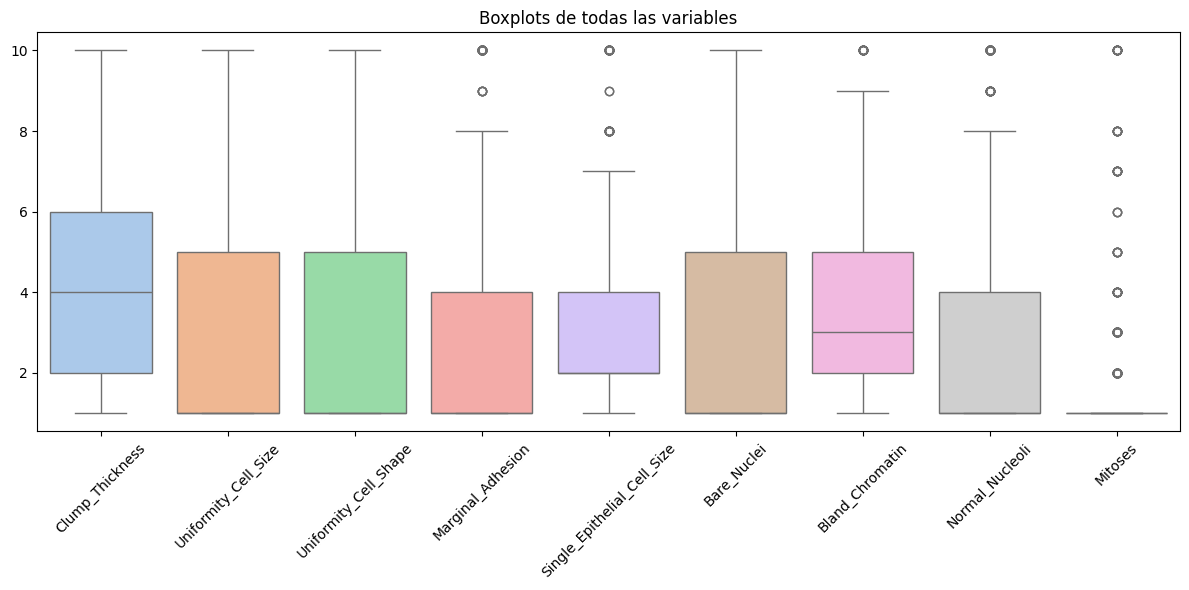

In [27]:
# En el grafico nos muestra la dispersion de los datos y algunos outliers por variable
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop("Class", axis=1), palette="pastel")
plt.title("Boxplots de todas las variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [32]:
X = df.drop("Class", axis=1)  # Variables independientes
y = df["Class"]               # Variable dependiente

In [30]:
# Separamo nuestros datos de entrenamiento y pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### b. Genere el modelo de árbol de decisión para clasificación y la profundidad adecuada para este. Además, calcule las métricas de clasificación e interprete sus resultados más importantes

In [41]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

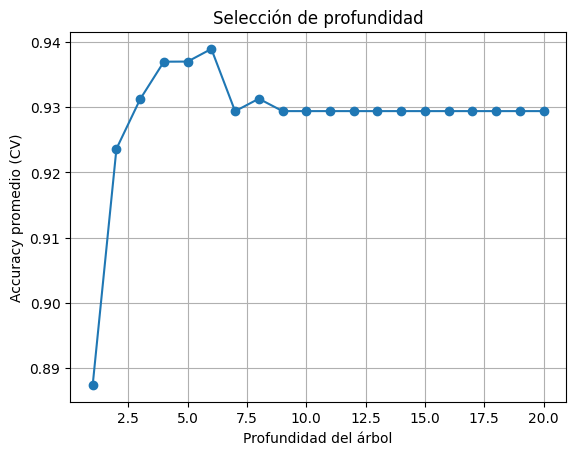

In [35]:
# Buscar profundidad óptima con validación cruzada
scores = []
for depth in range(1, 21):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    scores.append(score)

# Mostrar gráfico de accuracy vs profundidad
plt.plot(range(1, 21), scores, marker='o')
plt.xlabel("Profundidad del árbol")
plt.ylabel("Accuracy promedio (CV)")
plt.title("Selección de profundidad")
plt.grid(True)
plt.show()

In [36]:
# Elegir la mejor profundidad
best_depth = scores.index(max(scores)) + 1
print(f"Mejor profundidad: {best_depth}")

Mejor profundidad: 6


In [37]:
# Entrenar árbol con la mejor profundidad
tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

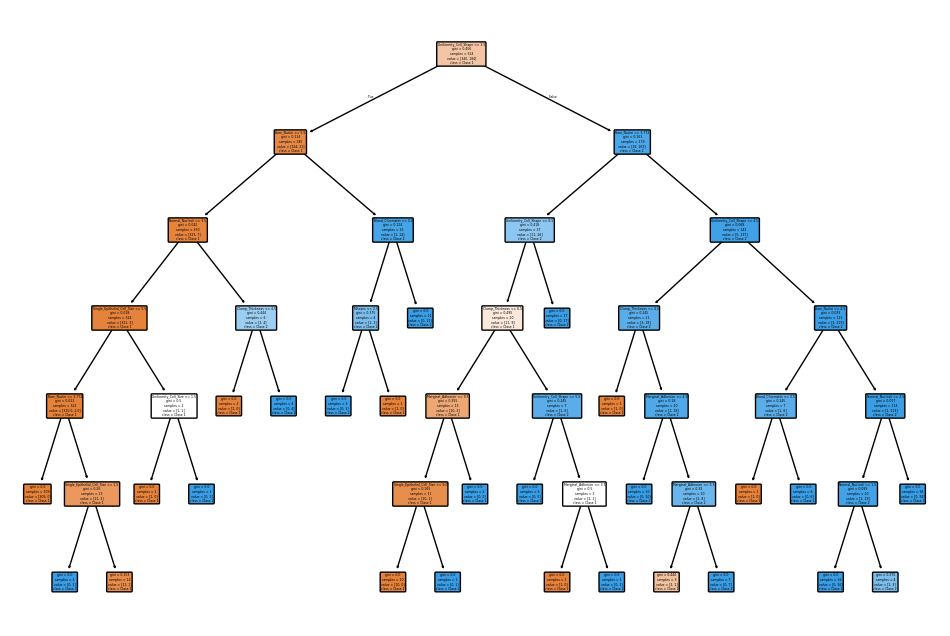

In [42]:
# Graficando el árbol
plt.figure(figsize=(12, 8))  # Tamaño de la figura
plot_tree(tree, filled=True, feature_names=X_train.columns, class_names=['Clase 1', 'Clase 2'], rounded=True)
plt.show()

In [38]:
# Predicciones y métricas
y_pred = tree.predict(X_test)
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Matriz de Confusión:
[[115   3]
 [  8  49]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           1       0.93      0.97      0.95       118
           2       0.94      0.86      0.90        57

    accuracy                           0.94       175
   macro avg       0.94      0.92      0.93       175
weighted avg       0.94      0.94      0.94       175



### c. Genere el modelo de bosques aleatorios para clasificación. Además, calcule las métricas de clasificación y compárelas con las del árbol de clasificación. ¿Hubo mejoras o no?

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar modelo de Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)

# Métricas
print("Matriz de Confusión (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf))


Matriz de Confusión (Random Forest):
[[115   3]
 [  3  54]]

Reporte de Clasificación (Random Forest):
              precision    recall  f1-score   support

           1       0.97      0.97      0.97       118
           2       0.95      0.95      0.95        57

    accuracy                           0.97       175
   macro avg       0.96      0.96      0.96       175
weighted avg       0.97      0.97      0.97       175



### Comparación de modelos

| Métrica                          | Árbol de Decisión | Bosques Aleatorios |
|-----------------------------------|-------------------|---------------------|
| **Accuracy**                      | 0.94              | 0.97 ✅              |
| **Precision (clase 1)**           | 0.93              | 0.97 ✅              |
| **Precision (clase 2)**           | 0.94              | 0.95 ✅              |
| **Recall (clase 1)**              | 0.97 ✅            | 0.97                |
| **Recall (clase 2)**              | 0.86              | 0.95 ✅              |
| **F1-score (clase 1)**            | 0.95              | 0.97 ✅              |
| **F1-score (clase 2)**            | 0.90              | 0.95 ✅              |
